In [ ]:
#model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "google/vivit-b-16x2-kinetics400"

batch_size = 4 # batch size for training and evaluation

from transformers import VideoMAEConfig, VideoMAEModel

# Initializing a VideoMAE videomae-base style configuration
configuration = VideoMAEConfig()

# Randomly initializing a model from the configuration
model = VideoMAEModel(configuration)

# Accessing the model configuration
configuration = model.config
print(configuration)

In [ ]:
import pathlib

output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/train-test stratified folding')

# Count videos in each set
video_count_train = len(list(output_root_path.glob("train/*/*.mp4")))
video_count_val = len(list(output_root_path.glob("val/*/*.mp4")))
video_count_test = len(list(output_root_path.glob("test/*/*.mp4")))

# Calculate total videos
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

# List all video file paths
all_video_file_paths = (
    list(output_root_path.glob("train/*/*.mp4")) +
    list(output_root_path.glob("val/*/*.mp4")) +
    list(output_root_path.glob("test/*/*.mp4"))
)

# Display the first five video file paths
print(all_video_file_paths[:5])

# Print total number of videos in each set and the first 5 video file paths for training
print(f"Total videos: {video_total}")
print(f"Training videos: {video_count_train}, Validation videos: {video_count_val}, Test videos: {video_count_test}")


Total videos: 9307
[PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/train-test stratified folding/train/cake/U5W44F_trial_6_R.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/train-test stratified folding/train/cake/U3W44F_trial_12_R.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/train-test stratified folding/train/cake/U13W44F_trial_0_L.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/train-test stratified folding/train/cake/U13W44F_trial_1_L.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/train-test stratified folding/train/cake/U12W44F_trial_5_R.mp4')]
Total videos: 9307
Training videos: 8031, Validation videos: 0, Test videos: 1276


In [7]:
# Adjust class label extraction logic
class_labels = sorted({str(path.parent.name) for path in all_video_file_paths})  # Use parent folder name as class label
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}
# Print the unique class labels and their mappings
print(f"Unique classes: {list(label2id.keys())}.")
print(f"Label to ID mapping: {label2id}")
#print(f"ID to Label mapping: {id2label}")

Unique classes: ['aam', 'aaple', 'ac', 'aids', 'alu', 'anaros', 'angur', 'apartment', 'attio', 'audio cassette', 'ayna', 'baandej', 'baat', 'baba', 'balti', 'balu', 'bhai', 'biscuts', 'bon', 'boroi', 'bottam', 'bou', 'cake', 'capsule', 'cha', 'chacha', 'chachi', 'chadar', 'chal', 'chikissha', 'chini', 'chips', 'chiruni', 'chocolate', 'chokh utha', 'chosma', 'churi', 'clip', 'cream', 'dada', 'dadi', 'daeitto', 'dal', 'debor', 'denadar', 'dengue', 'doctor', 'dongson', 'dulavai', 'durbol', 'jomoj', 'juta', 'konna', 'maa', 'tattha', 'toothpaste', 'tshirt', 'tubelight', 'tupi', 'tv'].
Label to ID mapping: {'aam': 0, 'aaple': 1, 'ac': 2, 'aids': 3, 'alu': 4, 'anaros': 5, 'angur': 6, 'apartment': 7, 'attio': 8, 'audio cassette': 9, 'ayna': 10, 'baandej': 11, 'baat': 12, 'baba': 13, 'balti': 14, 'balu': 15, 'bhai': 16, 'biscuts': 17, 'bon': 18, 'boroi': 19, 'bottam': 20, 'bou': 21, 'cake': 22, 'capsule': 23, 'cha': 24, 'chacha': 25, 'chachi': 26, 'chadar': 27, 'chal': 28, 'chikissha': 29, 'chi

In [8]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers import VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification

# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )

# image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,)

image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([60]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([60, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model configuration
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)
config = VideoMAEConfig.from_pretrained(model_ckpt)
#model_ckpt = "google/vivit-b-16x2-kinetics400"
#config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
print(f"Number of frames to sample: {num_frames_to_sample}")
sample_rate = 8
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

# Training dataset transformations.
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                    
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)



# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

# stratified

In [10]:
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model con
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)
config = VideoMAEConfig.from_pretrained(model_ckpt)
#model_ckpt = "google/vivit-b-16x2-kinetics400"
#config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
print(f"Number of frames to sample: {num_frames_to_sample}")
sample_rate = 8
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

# Training dataset transformations.
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                    
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)



# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
# val_dataset = pytorchvideo.data.Ucf101(
#     data_path=os.path.join(output_root_path, "val"),
#     clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
#     decode_audio=False,
#     transform=val_transform,
# )

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

Number of frames to sample: 16


In [11]:
print(train_dataset.num_videos)

8031


video torch.Size([3, 16, 224, 224])
video_name U2W5F_trial_2_R.mp4
video_index 2904
clip_index 0
aug_index 0
label 21
Video label: bou


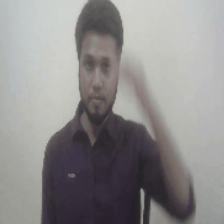

In [12]:
train_dataset.num_videos, test_dataset.num_videos
# train data sample
sample_video = next(iter(train_dataset))
sample_video.keys()
def investigate_video(sample_video):
    """Utility to investigate the keys present in a single video sample."""
    for k in sample_video:
        if k == "video":
            print(k, sample_video["video"].shape)
        else:
            print(k, sample_video[k])

    print(f"Video label: {id2label[sample_video[k]]}")

investigate_video(sample_video)

import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

video_tensor = sample_video["video"]
display_gif(video_tensor)
#print(video_tensor.shape)

In [13]:
import evaluate
import torch

metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions."""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)


def collate_fn(examples):
    """The collation function to be used by `Trainer` to prepare data batches."""
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
from huggingface_hub import login, hf_hub_download
# RnW token

# Authenticate using the API token
login(token=hf_token)


In [ ]:
import numpy as np
import torch
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from torchvision.transforms import Compose
from transformers import TrainingArguments, Trainer
import pytorchvideo.data
import evaluate
import json
from transformers import PreTrainedModel, EarlyStoppingCallback
import os
import subprocess


metric = evaluate.load("accuracy")

num_epochs = 10
k = 10

batch_size = 2

#output_dir=r'/media/cse/HDD/Shawon/shawon/10 fold timesformer/ViViT_default_fold_10_10_epoch_Aug_batch_1_4'


# Test directory
test_dir = os.path.join(output_root_path, "test")  
class_folders = [f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))]
class_labels = class_folders

# Load training files from the single train folder
train_data_path = os.path.join(output_root_path, "train")
train_class_folders = [f for f in os.listdir(train_data_path) if os.path.isdir(os.path.join(train_data_path, f))]
train_video_files = []
train_labels = []

# Gather video files and labels from the train folder
for train_class_folder in train_class_folders:
    train_class_folder_path = os.path.join(train_data_path, train_class_folder)
    train_videos = [os.path.join(train_class_folder_path, video) for video in os.listdir(train_class_folder_path) if video.endswith('.mp4')]
    train_video_files.extend(train_videos)
    train_labels.extend([train_class_folder] * len(train_videos))

train_video_files = np.array(train_video_files)
train_labels = np.array(train_labels)

# Stratified K-Fold cross-validation
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)




def plot_confusion_matrix(conf_matrix, class_labels, mode, fold=None, accuracy=None, precision=None, recall=None, f1=None):
   
    plt.figure(figsize=(12, 10))
    
    # Adjust fmt to '.2f' for floating-point numbers when plotting mean confusion matrix
    fmt = ".1f" if conf_matrix.dtype == 'float' else "d"  # only 1 decimal value
    # Plotting the heatmap
    sns.heatmap(conf_matrix, annot=True, fmt=fmt, cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)

    # Define the title based on the mode
    if mode == 'trainfold':
        title = f"VideoMAE_BdSLW60 | Train Fold {fold + 1} | Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"
    elif mode == 'kfold':
        title = f"VideoMAE_BdSLW60 | Valid Fold {fold + 1} | Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"
    elif mode == 'mean':
        title = f"VideoMAE_BdSLW60| Mean Valid Fold | Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"
    elif mode == 'mean_train':
        title = f"VideoMAE_BdSLW60 | Mean Train Fold | Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"
    elif mode == 'mean_test':
        title = f"VideoMAE_BdSLW60 | Mean Test Fold | Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"
    elif mode == 'test':
        title = f"VideoMAE_BdSLW60 | Test Fold {fold + 1} | Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"
    else:
        title = f"VideoMAE_BdSLW60| Fold {fold + 1 if fold is not None else ''} | Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"

    plt.title(title, fontsize=14)
    #plt.title(title)
    plt.tight_layout()

    # Save the confusion matrix image
    cm_filename = f"confusion_matrix_{mode}_fold_{fold + 1 if fold is not None else 'mean'}.png"
    #plt.savefig(cm_filename)
    plt.savefig(os.path.join(output_dir, cm_filename))
    
    # Show the plot
    
    plt.show()
    plt.close()


# Collate function to process the batches
def collate_fn(examples):
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}


# Initialize lists for tracking results across folds
val_accuracies = []
test_accuracies = []
all_val_predictions = []
all_val_labels = []
all_test_predictions = []
all_test_labels = []
all_conf_matrices = []
all_test_conf_matrices = []

# Initialize a list to store training accuracies
train_accuracies = []
all_train_predictions = []
all_train_labels = []
all_train_conf_matrices = []

# Track the best models
best_train_accuracy = 0  # Track the best training accuracy
best_val_accuracy = 0  
best_test_accuracy = 0  
best_train_model = None  # Track the best model for training accuracy
best_val_model = None   
best_test_model = None  

def compute_confusion_matrix(trainer, eval_dataset, eval_type, fold, class_labels):
    predictions_output = trainer.predict(eval_dataset)
    predictions = np.argmax(predictions_output.predictions, axis=1)
    labels = predictions_output.label_ids

    # Calculate metrics
    accuracy = metric.compute(predictions=predictions, references=labels)["accuracy"]
    conf_matrix = confusion_matrix(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )

    plot_confusion_matrix(
      conf_matrix,
      class_labels,
      fold=fold,  
      accuracy=accuracy,  
      precision=precision,
      recall=recall,
      f1=f1,
      mode=eval_type
    )
    return accuracy, precision, recall, f1, conf_matrix, predictions, labels



# Replace model_checkpoint with your actual pretrained model checkpoint path
model_ckpt="MCG-NJU/videomae-base-finetuned-kinetics"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#model_ckpt = "google/vivit-b-16x2-kinetics400"
#image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
#model_ckpt="facebook/timesformer-base-finetuned-k400"
#image_processor = AutoImageProcessor.from_pretrained(model_ckpt)
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,
# )
# Initialize lists for tracking metrics across folds

val_precisions, val_recalls, val_f1_scores = [], [], []
test_precisions, test_recalls, test_f1_scores = [], [], []
train_precisions, train_recalls, train_f1_scores = [], [], []

# Loop through each fold
for fold, (train_idx, val_idx) in enumerate(skf.split(train_video_files, train_labels)):

    output_dir = f'/media/cse/HDD/Shawon/shawon/10 fold timesformer/VideoMAE_default_fold__{fold}__10_epoch_bdslw60_kinetics_25_2_25'
    
    #log_dir = os.path.join(output_dir, "logs")

    # Launch TensorBoard
    # print(f"Launching TensorBoard at {log_dir}...")
    # subprocess.Popen(["tensorboard", "--logdir", log_dir, "--port", "6006"])# 6006

    print(f"Reloading model for fold {fold + 1}")
    # model_ckpt="facebook/timesformer-base-finetuned-k400"
    # image_processor = AutoImageProcessor.from_pretrained(model_ckpt)
    # model = TimesformerForVideoClassification.from_pretrained(
    # model_ckpt,
    # label2id=label2id,
    # id2label=id2label,
    # ignore_mismatched_sizes=True,
    # )
    # model.to(device)

    model_ckpt="MCG-NJU/videomae-base-finetuned-kinetics"
    image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
    model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
    )
    model.to(device)
    
    # model_ckpt = "google/vivit-b-16x2-kinetics400"
    # image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
    # model = VivitForVideoClassification.from_pretrained(
    # model_ckpt,
    # label2id=label2id,
    # id2label=id2label,
    # ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
    # ) 
    # model.to(device)


    # Split train and validation data
    train_files = train_video_files[train_idx]
    val_files = train_video_files[val_idx]
    train_labels_fold = train_labels[train_idx]
    val_labels_fold = train_labels[val_idx]

    temp_train_dir = os.path.join(output_root_path, f"fold_{fold}_train")
    temp_val_dir = os.path.join(output_root_path, f"fold_{fold}_val")

    os.makedirs(temp_train_dir, exist_ok=True)
    os.makedirs(temp_val_dir, exist_ok=True)

    # Copy training files for this fold
    for video, label in zip(train_files, train_labels_fold):
        label_dir = os.path.join(temp_train_dir, label)
        os.makedirs(label_dir, exist_ok=True)
        shutil.copy(video, label_dir)

    # Copy validation files for this fold
    for video, label in zip(val_files, val_labels_fold):
        label_dir = os.path.join(temp_val_dir, label)
        os.makedirs(label_dir, exist_ok=True)
        shutil.copy(video, label_dir)

    train_dataset = pytorchvideo.data.Ucf101(
        data_path=temp_train_dir,
        clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
        decode_audio=False,
        transform=train_transform,
    )

    val_dataset = pytorchvideo.data.Ucf101(
        data_path=temp_val_dir,
        clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
        decode_audio=False,
        transform=val_transform,
    )

    # Test dataset remains the same across all folds
    test_dataset = pytorchvideo.data.Ucf101(
        data_path=test_dir,
        clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
        decode_audio=False,
        transform=val_transform,
    )


    #max_steps= (train_dataset.num_videos // batch_size) * num_epochs
    
    max_steps=(train_dataset.num_videos // (2*4)) * num_epochs


    args = TrainingArguments(

       output_dir=output_dir,
       remove_unused_columns=False,
       save_strategy="epoch",
       evaluation_strategy="epoch",
       learning_rate=5e-5,
       per_device_train_batch_size=batch_size,
       per_device_eval_batch_size=batch_size,
       gradient_accumulation_steps=4,
       warmup_ratio=0.1,
       logging_steps=100,
       load_best_model_at_end=True,
       metric_for_best_model="accuracy",
       max_steps= max_steps,
       report_to=["none"],  
       #logging_dir=log_dir,
       fp16=True,
       
       weight_decay=0.01, # newly added
       push_to_hub=False,

    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=image_processor,
        compute_metrics=compute_metrics,
        data_collator=collate_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

    print(f"Training on fold {fold + 1}/{k}")
    trainer.train()
    trainer.save_model()


    # Load the accuracy metric
    accuracy_metric = evaluate.load("accuracy")

    # Compute training accuracy for this fold
    print(f"Computing training accuracy for fold {fold + 1}")
    # Compute training metrics
    train_accuracy, train_precision, train_recall, train_f1, train_conf_matrix, train_fold_predictions, train_fold_labels = compute_confusion_matrix(
        trainer, train_dataset, 'trainfold', fold, class_labels
    )
    train_accuracies.append(train_accuracy)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1_scores.append(train_f1)

    all_train_conf_matrices.append(train_conf_matrix)
    all_train_predictions.extend(train_fold_predictions)
    all_train_labels.extend(train_fold_labels)

    # Calculate accuracy using the evaluate library
    train_accuracy_result = accuracy_metric.compute(predictions=train_fold_predictions, references=train_fold_labels)
    print(f"Training Accuracy: {train_accuracy_result['accuracy']:.6f}")
    

    print(f"Computing val accuracy for fold {fold + 1}")
    # Compute validation metrics
    val_accuracy, val_precision, val_recall, val_f1, val_conf_matrix, val_fold_predictions, val_fold_labels = compute_confusion_matrix(
        trainer, val_dataset, 'kfold', fold, class_labels
    )
    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1_scores.append(val_f1)

    all_conf_matrices.append(val_conf_matrix)
    all_val_predictions.extend(val_fold_predictions)
    all_val_labels.extend(val_fold_labels)

    # Calculate accuracy using the evaluate library
    val_accuracy_result = accuracy_metric.compute(predictions=val_fold_predictions, references=val_fold_labels)
    print(f"Validation Accuracy: {val_accuracy_result['accuracy']:.6f}")

    # Evaluate on the test dataset
    print("Evaluating on the test dataset...")
    # Compute test metrics
    test_accuracy, test_precision, test_recall, test_f1, test_conf_matrix, test_fold_predictions, test_fold_labels = compute_confusion_matrix(
        trainer, test_dataset, 'test', fold, class_labels
    )
    test_accuracies.append(test_accuracy)
    test_precisions.append(test_precision)
    test_recalls.append(test_recall)
    test_f1_scores.append(test_f1)

    all_test_conf_matrices.append(test_conf_matrix)
    all_test_predictions.extend(test_fold_predictions)
    all_test_labels.extend(test_fold_labels)

    # Calculate accuracy for the test set
    test_accuracy_result = accuracy_metric.compute(predictions=test_fold_predictions, references=test_fold_labels)
    print(f"Test Accuracy: {test_accuracy_result['accuracy']:.6f}")

    # Optional: Log and save metrics if needed
    try:
        test_results = trainer.evaluate(test_dataset)
        trainer.log_metrics("test", test_results)
        trainer.save_metrics("test", test_results)
        trainer.save_state()
        trainer.push_to_hub()
    except Exception as e:
        print(f"An error occurred during test evaluation: {e}")

    # Update the best training model based on accuracy
    if train_accuracy > best_train_accuracy:
        best_train_accuracy = train_accuracy
        best_train_model = trainer.model

    # Save the best model based on validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_val_model = trainer.model

    # Save the best model based on test accuracy
    if test_accuracy > best_test_accuracy:
        best_test_accuracy = test_accuracy
        best_test_model = trainer.model

    shutil.rmtree(temp_train_dir)
    shutil.rmtree(temp_val_dir)


# Calculate mean training accuracy
mean_train_accuracy = np.mean(train_accuracies)
print(f"Mean Training Accuracy: {mean_train_accuracy:.6f}")
# Calculate mean validation and test accuracies
mean_val_accuracy = np.mean(val_accuracies)
mean_test_accuracy = np.mean(test_accuracies)
print(f"Mean Validation Accuracy: {mean_val_accuracy:.6f}")
print(f"Mean Test Accuracy: {mean_test_accuracy:.6f}")




mean_train_precision = np.mean(train_precisions)
mean_train_recall = np.mean(train_recalls)
mean_train_f1 = np.mean(train_f1_scores)

mean_val_precision = np.mean(val_precisions)
mean_val_recall = np.mean(val_recalls)
mean_val_f1 = np.mean(val_f1_scores)

mean_test_precision = np.mean(test_precisions)
mean_test_recall = np.mean(test_recalls)
mean_test_f1 = np.mean(test_f1_scores)


# Plot mean training confusion matrix
mean_train_conf_matrix = np.mean(all_train_conf_matrices, axis=0)
# Mean confusion matrices
mean_conf_matrix = np.mean(all_conf_matrices, axis=0)
mean_test_conf_matrix = np.mean(all_test_conf_matrices, axis=0)

print(f"Mean Training Accuracy: {mean_train_accuracy:.3f}, Precision: {mean_train_precision:.3f}, Recall: {mean_train_recall:.3f}, F1: {mean_train_f1:.3f}")
print(f"Mean Validation Accuracy: {mean_val_accuracy:.3f}, Precision: {mean_val_precision:.3f}, Recall: {mean_val_recall:.3f}, F1: {mean_val_f1:.3f}")
print(f"Mean Test Accuracy: {mean_test_accuracy:.3f}, Precision: {mean_test_precision:.3f}, Recall: {mean_test_recall:.3f}, F1: {mean_test_f1:.3f}")

plot_confusion_matrix(mean_train_conf_matrix, class_labels, accuracy=mean_train_accuracy, precision=mean_train_precision, recall=mean_train_recall, f1=mean_train_f1,mode='mean_train')
plot_confusion_matrix(mean_conf_matrix, class_labels, accuracy=mean_val_accuracy,precision=mean_val_precision, recall=mean_val_recall, f1=mean_val_f1, mode='mean')
plot_confusion_matrix(mean_test_conf_matrix, class_labels, accuracy=mean_test_accuracy, precision=mean_test_precision, recall=mean_test_recall, f1=mean_test_f1,mode='mean_test')